### **Лабораторная работа № 232**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [527]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.linewidth': 2,
    'lines.markersize': 6,
    'legend.frameon': True,
    'legend.edgecolor': 'black'
})

COLOR_EXP = "#E72F13"
COLOR_THEORY = "#1592DA"
COLOR_EXP2 = "#2C11DB"
COLOR_THEORY2 = "#CB1212"

In [528]:
def experimental_error(I):
    return 0.05 * np.abs(I) + 0.01

def plot_with_errors(x, y, y_err, label, color):
    plt.errorbar(x, y, yerr=y_err, fmt='o', capsize=3, capthick=1.5,
                 label=label, color=color, markeredgecolor='black', zorder=5)

def plot_theory_curve(x, y, label, color):
    plt.plot(x, y, color=color, label=label)

In [529]:
# Зависимость I от угла
no_phase_degrees = np.arange(0, 190, 10)
no_phase = np.array([0, 0.07, 0.18, 0.37, 0.62, 0.85, 1.06, 1.22, 1.32, 1.34, 1.28, 1.14, 0.95, 0.75, 0.52, 0.27, 0.12, 0.02, 0.01])

# Отражение от зеркало при вариации угла поляризатора
degreeses_step_10 = np.array([40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220])
dark_mirror = np.array([0.01, 0.01, 0.02, 0.04, 0.08, 0.14, 0.19, 0.24, 0.28, 0.30, 0.31, 0.30, 0.27, 0.23, 0.18, 0.13, 0.07, 0.04, 0.01])

# Отражение при перпендикудярной поляризации от угла падения на зеркало
brust_50_degreeses = np.array([15, 20, 25, 30, 35, 40, 45, 50, 55, 56, 57, 58, 59, 60, 65, 70, 75, 80])
bruster_min = np.array([0.11, 0.11, 0.1, 0.09, 0.08, 0.07, 0.06, 0.05, 0.04, 0.04, 0.04, 0.04, 0.05, 0.05, 0.06, 0.13, 0.33, 0.48])

# Отражение при параллельной поляризации от угла падения на зеркало
bruster_140_degrees = np.array([15, 20, 25, 30, 35, 40, 45, 50, 55, 56, 57, 58, 59, 60, 65, 70, 75, 80])
bruster_max = np.array([0.12, 0.13, 0.14, 0.15, 0.16, 0.18, 0.21, 0.23, 0.29, 0.3, 0.3, 0.32, 0.35, 0.34, 0.45, 0.62, 0.72, 0.86])

# Прохождение отразившегося под углом Брюстера от зеркала через анализатор
plast_degrees = np.arange(50, 240, 10)
plast = np.array([0., 0.01, 0.03, 0.06, 0.09, 0.12, 0.15, 0.17, 0.19, 0.19, 0.19, 0.17, 0.14, 0.11, 0.08, 0.05, 0.03, 0.01, 0.01])

#### **Часть 1. Закон Малюса**

In [530]:
def malus_theory(I0, angles, phi0=0):
    return I0 * (np.cos(np.radians(angles - phi0)))**2

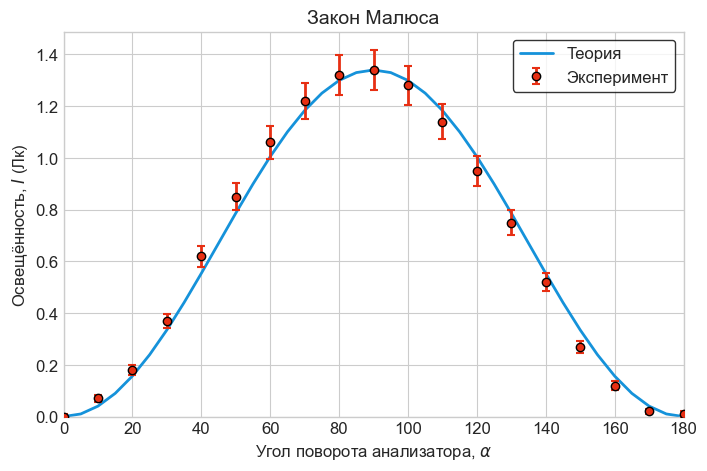

In [531]:
plt.figure(figsize=(8, 5))
plt.title("Закон Малюса")

angles = no_phase_degrees
I0 = np.max(no_phase)
phi0 = 90

angles_dense = np.arange(0, 185, 5)
theory = malus_theory(I0, angles_dense, phi0)

plot_with_errors(angles, no_phase, experimental_error(no_phase), "Эксперимент", COLOR_EXP)
plot_theory_curve(angles_dense, theory, "Теория", COLOR_THEORY)

plt.xlabel(r"Угол поворота анализатора, $\alpha$")
plt.ylabel("Освещённость, $I$ (Лк)")
plt.legend()
plt.xlim(0, 180)
plt.ylim(0)
plt.show()
plt.close()

#### **Часть 2. Зависимость коэффициента отражения от характера поляризации падающей волны при фиксированном угле падения**

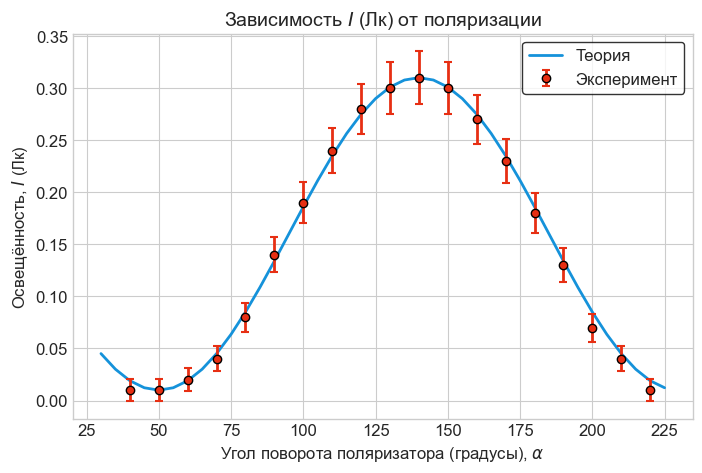

In [532]:
plt.figure(figsize=(8, 5))
plt.title("Зависимость $I$ (Лк) от поляризации")

idx_max = np.argmax(dark_mirror)
phi_max = degreeses_step_10[idx_max]

plot_with_errors(degreeses_step_10, dark_mirror, experimental_error(dark_mirror), "Эксперимент", COLOR_EXP)

angles_dense_2a = np.arange(30, 230, 5)
A = np.min(dark_mirror)
B = np.max(dark_mirror) - A
theory_mirror = A + B * (np.cos(np.radians(angles_dense_2a - 140)))**2
plot_theory_curve(angles_dense_2a, theory_mirror, "Теория", COLOR_THEORY)

plt.xlabel(r"Угол поворота поляризатора (градусы), $\alpha$")
plt.ylabel("Освещённость, $I$ (Лк)")
plt.legend()
plt.show()
plt.close()

#### **Часть 3. Зависимость интенсивности отраженного света от угла падения на зеркало поляризованного света:**
**1)	в плоскости, параллельной плоскости падения;**  
**2)	в плоскости, перпендикулярной плоскости падения.**

In [533]:
def fresnel_reflection(theta_deg, n=1.5):
    theta = np.radians(theta_deg)
    sin_t = np.sin(theta) / n
    theta_t = np.arcsin(sin_t)
    R_perp = (np.sin(theta - theta_t) / np.sin(theta + theta_t))**2
    R_parallel = (np.tan(theta - theta_t) / np.tan(theta + theta_t))**2
    return R_perp, R_parallel


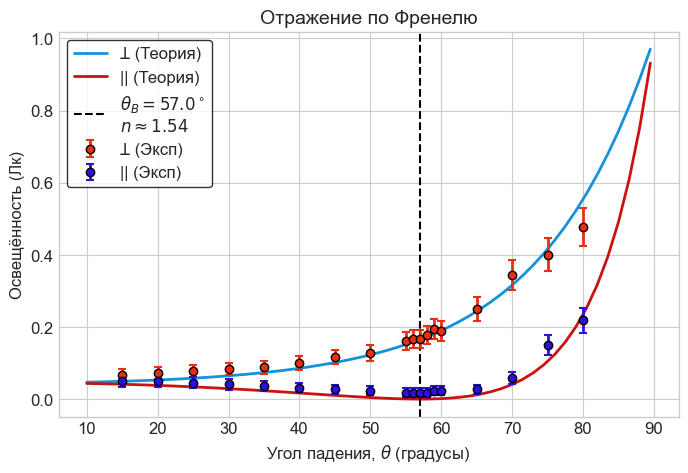

In [534]:
plt.figure(figsize=(8, 5))
plt.title("Отражение по Френелю")

min_idx = 10
brewster_angle = brust_50_degreeses[min_idx]
n_calc = np.tan(np.radians(brewster_angle))

angles_dense = np.arange(10, 90, 1.5)
R_perp, R_parallel = fresnel_reflection(angles_dense, n=n_calc)

b_max = 1.8
b_min = 2.2
plot_with_errors(bruster_140_degrees, bruster_max/b_max, experimental_error(bruster_max),
                 "Ʇ (Эксп)", COLOR_EXP)
plot_theory_curve(angles_dense, R_perp,
                  "Ʇ (Теория)", COLOR_THEORY)

plot_with_errors(brust_50_degreeses, bruster_min/b_min, experimental_error(bruster_min),
                 "|| (Эксп)", COLOR_EXP2)

plot_theory_curve(angles_dense, R_parallel,
                  "|| (Теория)", COLOR_THEORY2)

plt.axvline(brewster_angle, color='black', linestyle='--', linewidth=1.5,
            label=fr"$\theta_B = {brewster_angle:.1f}^\circ$" + "\n" +
                  fr"$n \approx {n_calc:.2f}$")
plt.xlabel(r"Угол падения, $\theta$ (градусы)")
plt.ylabel("Освещённость (Лк)")
plt.legend()
plt.show()
plt.close()

#### **Часть 4. Задавая угол падения равным углу Брюстера, покажите, что отраженный свет линейно поляризован**

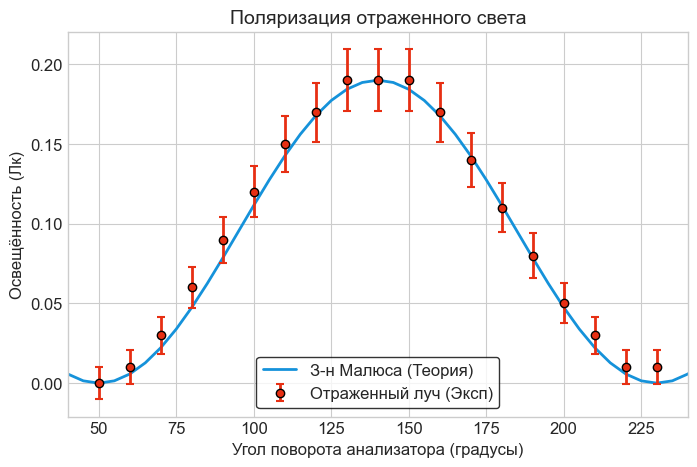

In [535]:
plt.figure(figsize=(8, 5))
plt.title("Поляризация отраженного света")

idx_max_plast = np.argmax(plast)
phi_plast = plast_degrees[idx_max_plast] 

plot_with_errors(plast_degrees, plast, experimental_error(plast),
                 "Отраженный луч (Эксп)", COLOR_EXP)

angles_dense2 = np.arange(40, 250, 5)
A_plast = np.min(plast)
B_plast = np.max(plast) - A_plast
theory_plast = A_plast + B_plast * (np.cos(np.radians(angles_dense2 - 140)))**2

plot_theory_curve(angles_dense2, theory_plast,
                  "З-н Малюса (Теория)", COLOR_THEORY)

plt.xlabel("Угол поворота анализатора (градусы)")
plt.ylabel("Освещённость (Лк)")
plt.xlim(40, 240) 
plt.legend()
plt.show()
plt.close()

Вопросы на сдаче:
1) Что было приемником
2) Есть два источника, первый - естественная поляризация, второй - поляризация по кругу, все остальное одинаково. Как их различить? 
3) Будет ли крутящий момент? 